# Imports and Read CSV File

In [1]:

import numpy as np
import pandas as pd
from pandas import read_csv
import matplotlib.pyplot as plt

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    mean_absolute_percentage_error
)

In [2]:
df = read_csv('../data/BTC-USD/BTC-USD_from_2010-01-01_till_2026-01-03.csv')
df.head()

,Date,Close,High,Low,Open,Volume
0,2014-09-17,457.334015,468.174011,452.421997,465.864014,21056800
1,2014-09-18,424.440002,456.859985,413.104004,456.859985,34483200
2,2014-09-19,394.795990,427.834991,384.532013,424.102997,37919700
3,2014-09-20,408.903992,423.295990,389.882996,394.673004,36863600
4,2014-09-21,398.821014,412.425995,393.181000,408.084991,26580100


# Understand The Data

In [3]:
df.tail()

,Date,Close,High,Low,Open,Volume
4121,2025-12-29,87138.140625,90299.156250,86717.914062,87835.789062,48411625849
4122,2025-12-30,88430.132812,89297.937500,86735.546875,87134.351562,35586356225
4123,2025-12-31,87508.828125,89080.289062,87130.562500,88429.585938,33830210616
4124,2026-01-01,88731.984375,88803.226562,87399.406250,87508.046875,18849043990
4125,2026-01-02,89944.695312,90884.460938,88298.617188,88733.062500,46398906171


In [4]:
df.shape

(4126, 6)

## Setting Date as Index

In [5]:
# Set Date as index for time series analysis

df['Date'] = pd.to_datetime(df['Date'])
df.set_index('Date', inplace=True)


In [6]:
df.tail()

,Close,High,Low,Open,Volume
Date,,,,,
2025-12-29,87138.140625,90299.156250,86717.914062,87835.789062,48411625849
2025-12-30,88430.132812,89297.937500,86735.546875,87134.351562,35586356225
2025-12-31,87508.828125,89080.289062,87130.562500,88429.585938,33830210616
2026-01-01,88731.984375,88803.226562,87399.406250,87508.046875,18849043990
2026-01-02,89944.695312,90884.460938,88298.617188,88733.062500,46398906171


# Applying ML Models

In [ ]:
df.tail()

## Random Forest

In [7]:
df_random_forest = df.copy()

In [8]:
df_random_forest.tail()

,Close,High,Low,Open,Volume
Date,,,,,
2025-12-29,87138.140625,90299.156250,86717.914062,87835.789062,48411625849
2025-12-30,88430.132812,89297.937500,86735.546875,87134.351562,35586356225
2025-12-31,87508.828125,89080.289062,87130.562500,88429.585938,33830210616
2026-01-01,88731.984375,88803.226562,87399.406250,87508.046875,18849043990
2026-01-02,89944.695312,90884.460938,88298.617188,88733.062500,46398906171


### Defining Features and Targets

In [9]:
# Create lag features
def create_lags(df, column='Close', lags=5):
    df = df.copy()
    for lag in range(1, lags+1):
        df[f'lag_{lag}'] = df[column].shift(lag)
    df['target'] = df[column].shift(-1)  # Predict next day
    return df.dropna()


# Apply
df_features = create_lags(df_random_forest, 'Close', lags=5)
X = df_features.drop(['target'], axis=1, errors='ignore')
y = df_features['target']

### Test-Train Split

In [10]:
# # Time series split (80/20)
# split_idx = int(len(X) * 0.8)
# X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
# y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

# dates_test = df_features.index[split_idx:]

# print(f"Train: {len(X_train)}, Test: {len(X_test)}")

In [11]:
from sklearn.model_selection import TimeSeriesSplit
from sklearn.ensemble import RandomForestRegressor

tscv = TimeSeriesSplit(n_splits=5)

y_true_all = []
y_pred_all = []
dates_all = []

model = RandomForestRegressor(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

for train_idx, test_idx in tscv.split(X):
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    y_true_all.extend(y_test.values)
    y_pred_all.extend(y_pred)
    dates_all.extend(X_test.index)

### Prediction and Plot

In [12]:
y_true_all = np.array(y_true_all)
y_pred_all = np.array(y_pred_all)

mae = mean_absolute_error(y_true_all, y_pred_all)
mse = mean_squared_error(y_true_all, y_pred_all)
rmse = np.sqrt(mse)
r2 = r2_score(y_true_all, y_pred_all)
mape = mean_absolute_percentage_error(y_true_all, y_pred_all) * 100
rmse_pct_avg = (rmse / y_true_all.mean()) * 100

print(f"MAE  : {mae:.4f}")
print(f"MSE  : {mse:.4f}")
print(f"RMSE : {rmse:.4f}")
print(f"R²   : {r2:.4f}")
print(f"MAPE : {mape:.2f}%")
print(f"RMSE % of Avg: {rmse_pct_avg:.2f}%")

MAE  : 9657.1952
MSE  : 308079450.3314
RMSE : 17552.1922
R²   : 0.7023
MAPE : 26.59%
RMSE % of Avg: 54.41%


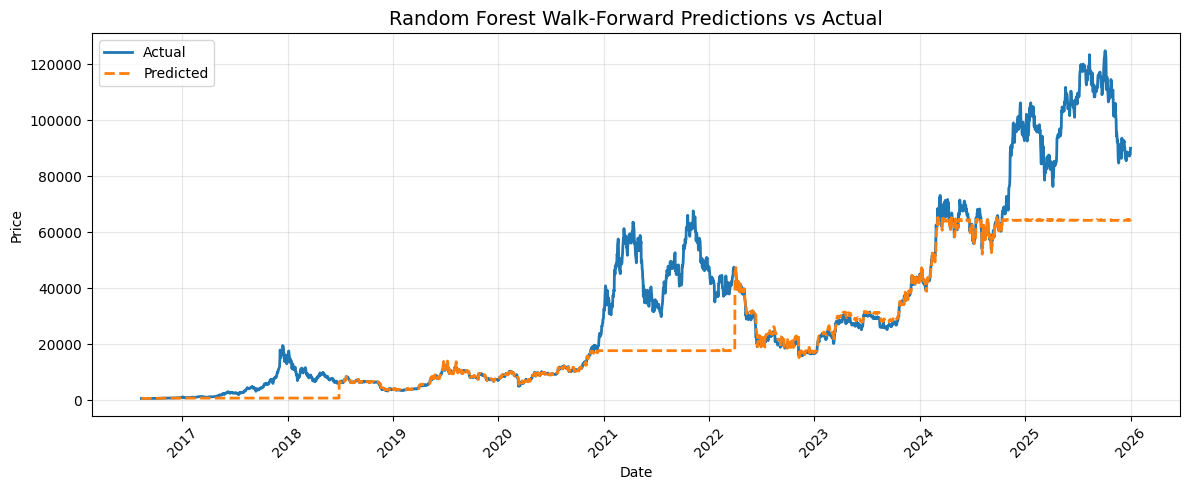

In [13]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))

plt.plot(dates_all, y_true_all, label='Actual', linewidth=2)
plt.plot(dates_all, y_pred_all, '--', label='Predicted', linewidth=2)

plt.title('Random Forest Walk-Forward Predictions vs Actual', fontsize=14)
plt.xlabel('Date')
plt.ylabel('Price')
plt.legend()
plt.grid(alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### n years of Forecast 

In [14]:
def predict_next_days(model, last_row, days):
    """
    Recursive multi-step forecasting for ML models
    last_row: DataFrame with same columns as X (1 row)
    """
    predictions = []
    current_row = last_row.copy()

    for _ in range(days):
        # Predict next value
        next_pred = model.predict(current_row)[0]
        predictions.append(next_pred)

        lag_cols = [
            col for col in current_row.columns if col.startswith("lag_")]

        for i in range(len(lag_cols), 1, -1):
            current_row[f"lag_{i}"] = current_row[f"lag_{i-1}"]

        current_row["lag_1"] = next_pred

    return np.array(predictions)

In [15]:
# Forecast horizon
n_days = 365

# Start forecast from the next day after last observation
start_date = df.index[-1] + pd.Timedelta(days=1)

future_dates = pd.date_range(
    start=start_date,
    periods=n_days,
    freq='D'
)

last_row = X.iloc[[-1]].copy()

# Predict next 365 days
next_prices = predict_next_days(
    model,
    last_row,
    days=n_days
)

In [16]:
forecast_df = pd.DataFrame({
    "date": future_dates,
    "forecast_price": next_prices
}).set_index("date")

predicted_df = pd.DataFrame({
    "date": dates_all,
    "predicted": y_pred_all
}).set_index("date").sort_index()

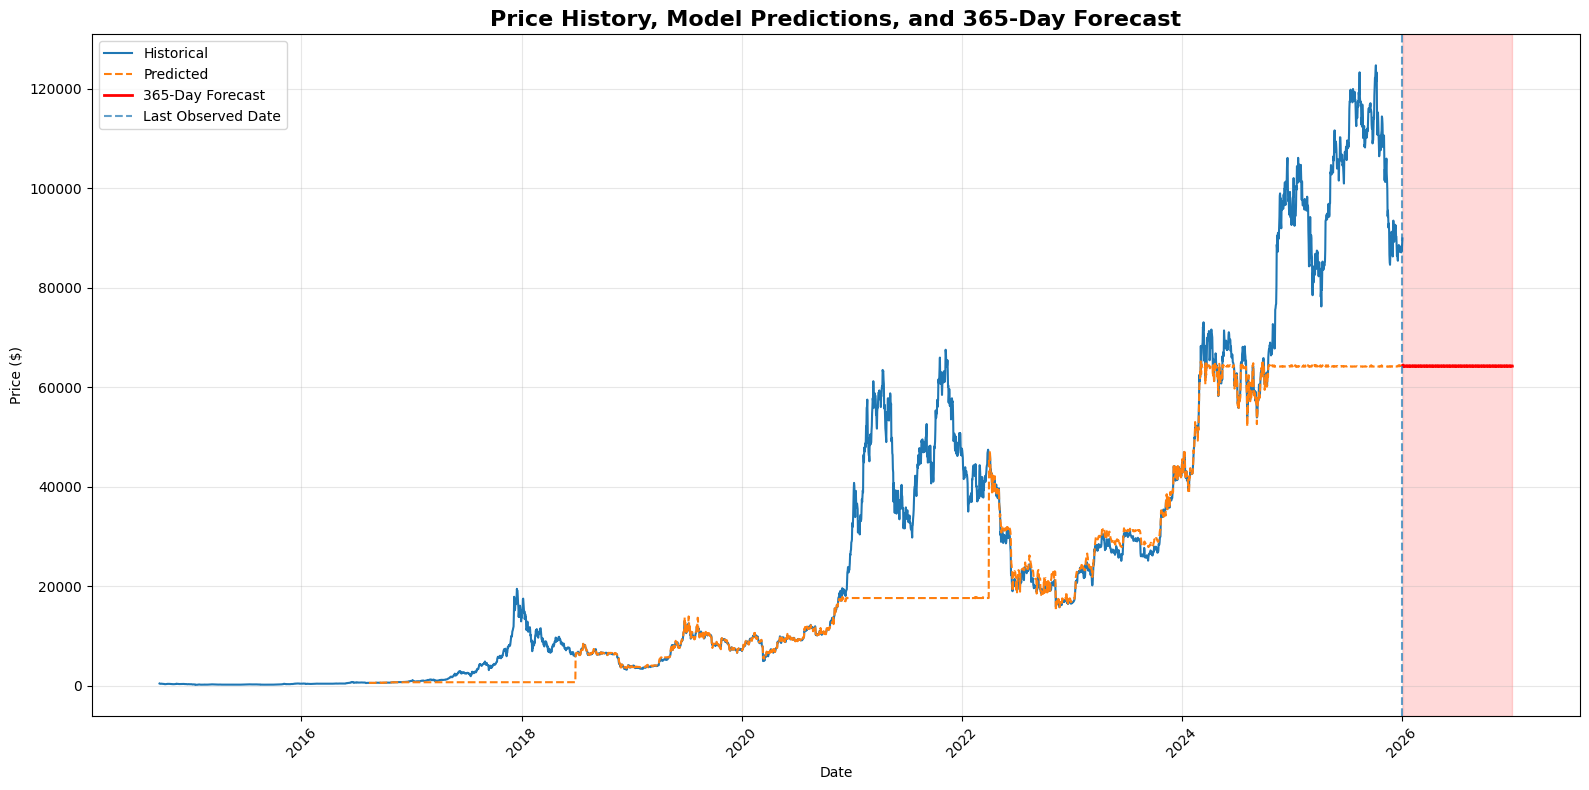

In [17]:
import matplotlib.pyplot as plt

plt.figure(figsize=(16, 8))

# Historical prices
plt.plot(
    df_random_forest.index,
    df_random_forest['Close'],
    label='Historical',
    linewidth=1.5
)

# Predicted prices (model on known data)
plt.plot(
    predicted_df.index,
    predicted_df['predicted'],
    label='Predicted',
    linewidth=1.5,
    linestyle='--'
)

# Forecast (future)
plt.plot(
    future_dates,
    next_prices,
    label='365-Day Forecast',
    linewidth=2,
    color='red'
)

# Highlight forecast period
plt.axvspan(
    future_dates[0],
    future_dates[-1],
    alpha=0.15,
    color='red'
)

# Last observed date
plt.axvline(
    df.index[-1],
    linestyle='--',
    alpha=0.7,
    label='Last Observed Date'
)

plt.title(
    'Price History, Model Predictions, and 365-Day Forecast',
    fontsize=16,
    fontweight='bold'
)
plt.xlabel('Date')
plt.ylabel('Price ($)')
plt.legend()
plt.grid(alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## ARIMA

In [149]:
df_arima = df.copy()
df_arima.tail()

,Close,High,Low,Open,Volume
Date,,,,,
2025-12-29,87138.140625,90299.156250,86717.914062,87835.789062,48411625849
2025-12-30,88430.132812,89297.937500,86735.546875,87134.351562,35586356225
2025-12-31,87508.828125,89080.289062,87130.562500,88429.585938,33830210616
2026-01-01,88731.984375,88803.226562,87399.406250,87508.046875,18849043990
2026-01-02,89944.695312,90884.460938,88298.617188,88733.062500,46398906171


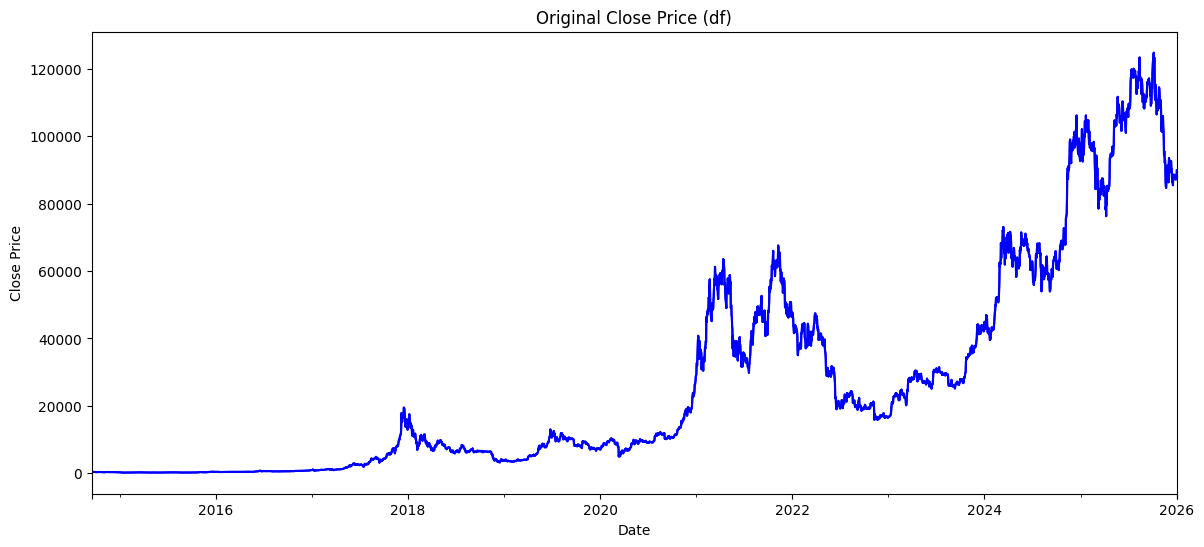

In [150]:
%matplotlib inline
# Add grid for better readability
df_arima['Close'].plot(
    figsize=(14, 6), title='Original Close Price (df)', color='blue', grid=True)

# Add axis labels
ax = df_arima['Close'].plot(
    figsize=(14, 6), title='Original Close Price (df)', color='blue')
ax.set_xlabel('Date')
ax.set_ylabel('Close Price')

# Show the plot (if not in Jupyter)
plt.show()

### Check For Stationary

In [151]:
from statsmodels.tsa.stattools import adfuller
# Test for stationarity
def check_stationarity(timeseries):
    result = adfuller(timeseries, autolag='AIC')
    print(f'ADF Statistic: {result[0]}')
    print(f'p-value: {result[1]}')
    if result[1] <= 0.05:
        print("Series is stationary")
        return True
    else:
        print("Series is not stationary")
        return False


# Check if Close price is stationary
is_stationary = check_stationarity(df_arima['Close'])

# If not stationary, apply differencing
if not is_stationary:
    df_arima['Close_diff'] = df_arima['Close'].diff().dropna()
    check_stationarity(df_arima['Close_diff'].dropna())
else:
    df_arima['Close_diff'] = df_arima['Close']

ADF Statistic: -0.736700311978211
p-value: 0.8370129759206062
Series is not stationary
ADF Statistic: -9.602051840264801
p-value: 1.9090154840622847e-16
Series is stationary


### Finding parameters using PCF and PACF Plot

In [152]:

from statsmodels.tsa.arima.model import ARIMA
# Determine ARIMA parameters using ACF and PACF
# This is a simplified approach - you might want to use auto_arima
def find_best_arima_params(data, max_p=3, max_d=2, max_q=3):
    best_aic = float('inf')
    best_params = None

    for p in range(max_p + 1):
        for d in range(max_d + 1):
            for q in range(max_q + 1):
                try:
                    model = ARIMA(data, order=(p, d, q))
                    fitted_model = model.fit()
                    if fitted_model.aic < best_aic:
                        best_aic = fitted_model.aic
                        best_params = (p, d, q)
                except:
                    continue
    return best_params


# Find best parameters (this might take a while)
print("Finding best ARIMA parameters...")
best_params = find_best_arima_params(df_arima['Close_diff'])
print(f"Best ARIMA parameters: {best_params}")

Finding best ARIMA parameters...
Best ARIMA parameters: (2, 2, 2)


In [153]:
df_arima.dropna(inplace=True)

In [154]:
df_arima.tail()

,Close,High,Low,Open,Volume,Close_diff
Date,,,,,,
2025-12-29,87138.140625,90299.156250,86717.914062,87835.789062,48411625849,-697.695312
2025-12-30,88430.132812,89297.937500,86735.546875,87134.351562,35586356225,1291.992188
2025-12-31,87508.828125,89080.289062,87130.562500,88429.585938,33830210616,-921.304688
2026-01-01,88731.984375,88803.226562,87399.406250,87508.046875,18849043990,1223.156250
2026-01-02,89944.695312,90884.460938,88298.617188,88733.062500,46398906171,1212.710938


### Spliting Data

In [159]:
# Split data (80-20 split, preserving time order)
split_idx = int(len(df_arima) * 0.8)
train_data = df_arima['Close'][:split_idx]
test_data = df_arima['Close'][split_idx:]

### Fiting the Model

In [160]:
# Fit ARIMA model
arima_model = ARIMA(train_data, order=best_params)
arima_fitted = arima_model.fit()

### Evaluation

#### Prediction

In [161]:
# Make predictions
predictions = arima_fitted.forecast(steps=len(test_data))
predictions = pd.Series(predictions, index=test_data.index)
# print(predictions)

#### Forecast

#### Error Metrics

In [165]:
# Calculate metrics
arima_mae = mean_absolute_error(test_data, predictions)
arima_mse = mean_squared_error(test_data, predictions)
arima_rmse = np.sqrt(arima_mse)
arima_r2 = r2_score(test_data, predictions)
arima_mape = mean_absolute_percentage_error(test_data, predictions) * 100

print(f"ARIMA Results:")
print(f"MAE: {arima_mae:.4f}")
print(f"MSE: {arima_mse:.4f}")
print(f"RMSE: {arima_rmse:.4f}")
print(f"R²: {arima_r2:.4f}")
print(f"MAPE: {arima_mape:.2f}%")

ARIMA Results:
MAE: 48190.6322
MSE: 2902253483.7289
RMSE: 53872.5671
R²: -3.3616
MAPE: 56.65%


#### Final Plot

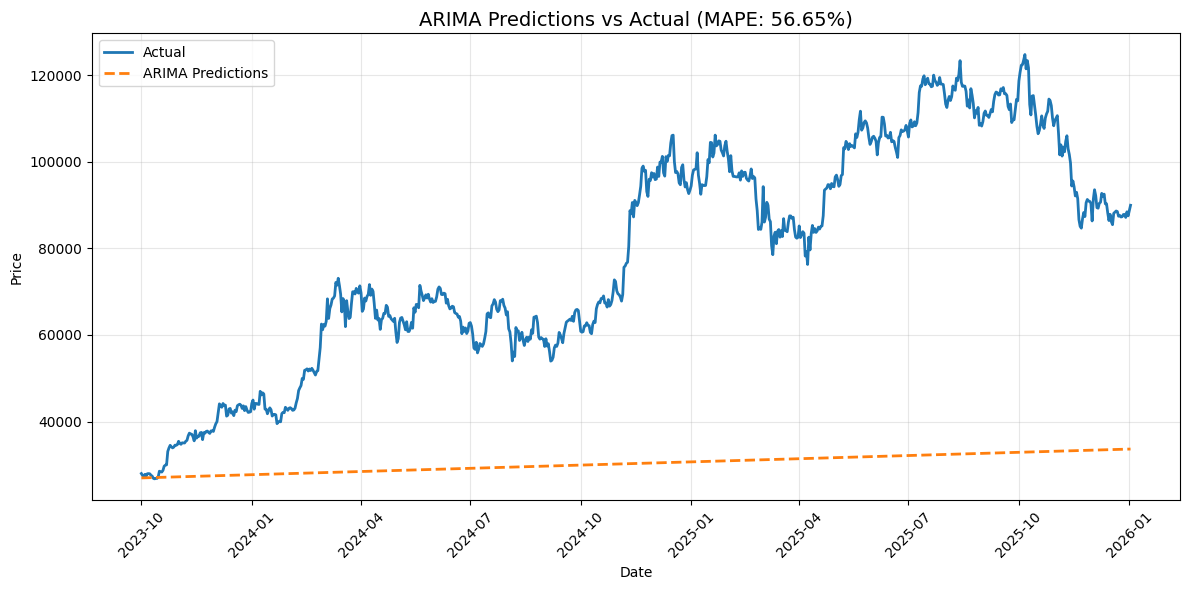

In [166]:
# plt.figure(figsize=(16, 8))

# # Historical prices (FULL history)
# plt.plot(
#     df_arima.index,
#     df_arima['Close'],
#     label='Historical',
#     linewidth=1.5
# )

# # Predicted prices (test period)
# plt.plot(
#     predicted_series.index,
#     predicted_series,
#     label='Predicted',
#     linestyle='--',
#     linewidth=2
# )

# # Future forecast
# plt.plot(
#     future_forecast_series.index,
#     future_forecast_series,
#     label='365-Day Forecast',
#     color='red',
#     linewidth=2
# )

# # Highlight forecast region
# plt.axvspan(
#     future_forecast_series.index[0],
#     future_forecast_series.index[-1],
#     color='red',
#     alpha=0.15
# )

# # Last observed date
# plt.axvline(
#     df_arima.index[-1],
#     linestyle='--',
#     alpha=0.7,
#     label='Last Observed Date'
# )

# plt.title(
#     'Price History, Model Predictions, and 365-Day Forecast',
#     fontsize=16,
#     fontweight='bold'
# )
# plt.xlabel('Date')
# plt.ylabel('Price ($)')
# plt.legend()
# plt.grid(alpha=0.3)
# plt.xticks(rotation=45)
# plt.tight_layout()
# plt.show()
# Plot ARIMA results

plt.figure(figsize=(12, 6))
plt.plot(test_data.index, test_data.values, label='Actual', linewidth=2)
plt.plot(predictions.index, predictions.values, '--',
         label='ARIMA Predictions', linewidth=2)
plt.title(
    f'ARIMA Predictions vs Actual (MAPE: {arima_mape:.2f}%)', fontsize=14)
plt.xlabel('Date')
plt.ylabel('Price')
plt.legend()
plt.grid(alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### SARIMA

In [167]:
# If you need results in seconds, not minutes
def quick_sarima(data, test_size):
    """Super fast SARIMA with fixed parameters"""
    # Use only recent data for faster fitting
    recent_data = data.tail(min(1000, len(data)))  # Last 1000 points max

    # Simple seasonal model
    from statsmodels.tsa.exponential_smoothing.ets import ETSModel

    try:
        # ETS is much faster than SARIMA
        ets_model = ETSModel(
            recent_data,
            error='add',
            trend='add',
            seasonal='add',
            seasonal_periods=365
        )
        fitted = ets_model.fit()
        predictions = fitted.forecast(steps=test_size)
        return predictions
    except:
        # Fallback to simple ARIMA
        from statsmodels.tsa.arima.model import ARIMA
        simple_model = ARIMA(recent_data, order=(1, 1, 1))
        fitted = simple_model.fit()
        predictions = fitted.forecast(steps=test_size)
        return predictions


print("\nFitting QUICK model...")
quick_predictions = quick_sarima(train_data, len(test_data))
quick_predictions = pd.Series(quick_predictions, index=test_data.index)

quick_mape = mean_absolute_percentage_error(test_data, quick_predictions) * 100
print(f"Quick Model MAPE: {quick_mape:.2f}%")


Fitting QUICK model...
Quick Model MAPE: 61.35%


#### SARIMA Metrix

#### Plotting

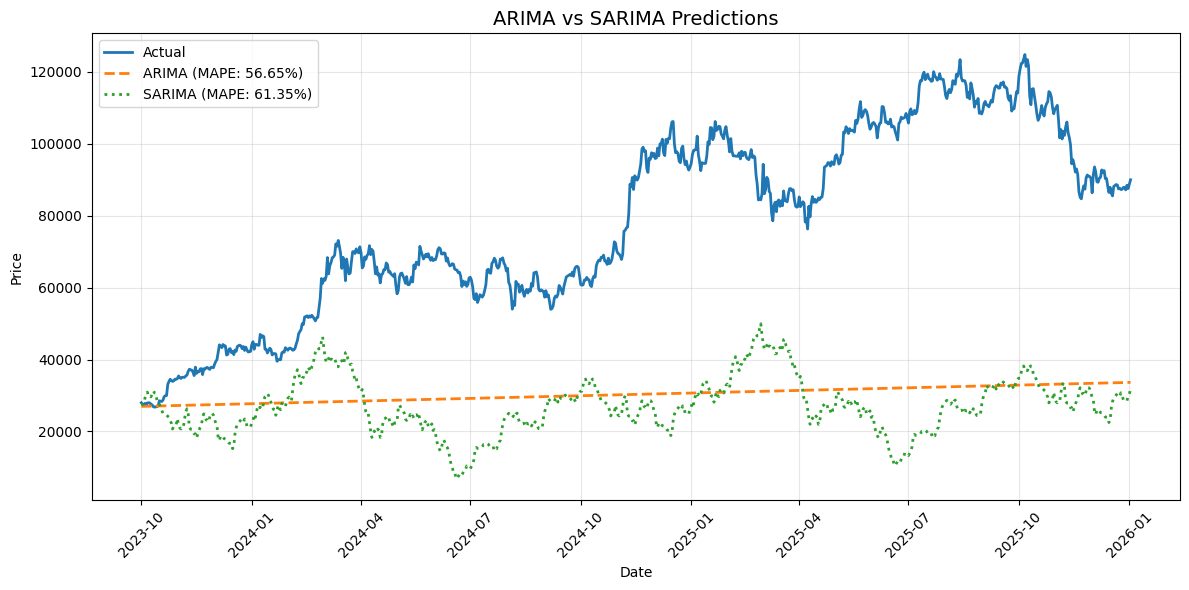

In [169]:
# Plot comparison
plt.figure(figsize=(12, 6))
plt.plot(test_data.index, test_data.values, label='Actual', linewidth=2)
plt.plot(predictions.index, predictions.values, '--',
         label=f'ARIMA (MAPE: {arima_mape:.2f}%)', linewidth=2)
plt.plot(quick_predictions.index, quick_predictions.values, ':',
         label=f'SARIMA (MAPE: {quick_mape:.2f}%)', linewidth=2)
plt.title('ARIMA vs SARIMA Predictions', fontsize=14)
plt.xlabel('Date')
plt.ylabel('Price')
plt.legend()
plt.grid(alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Generating 365-day forecast starting from next day...


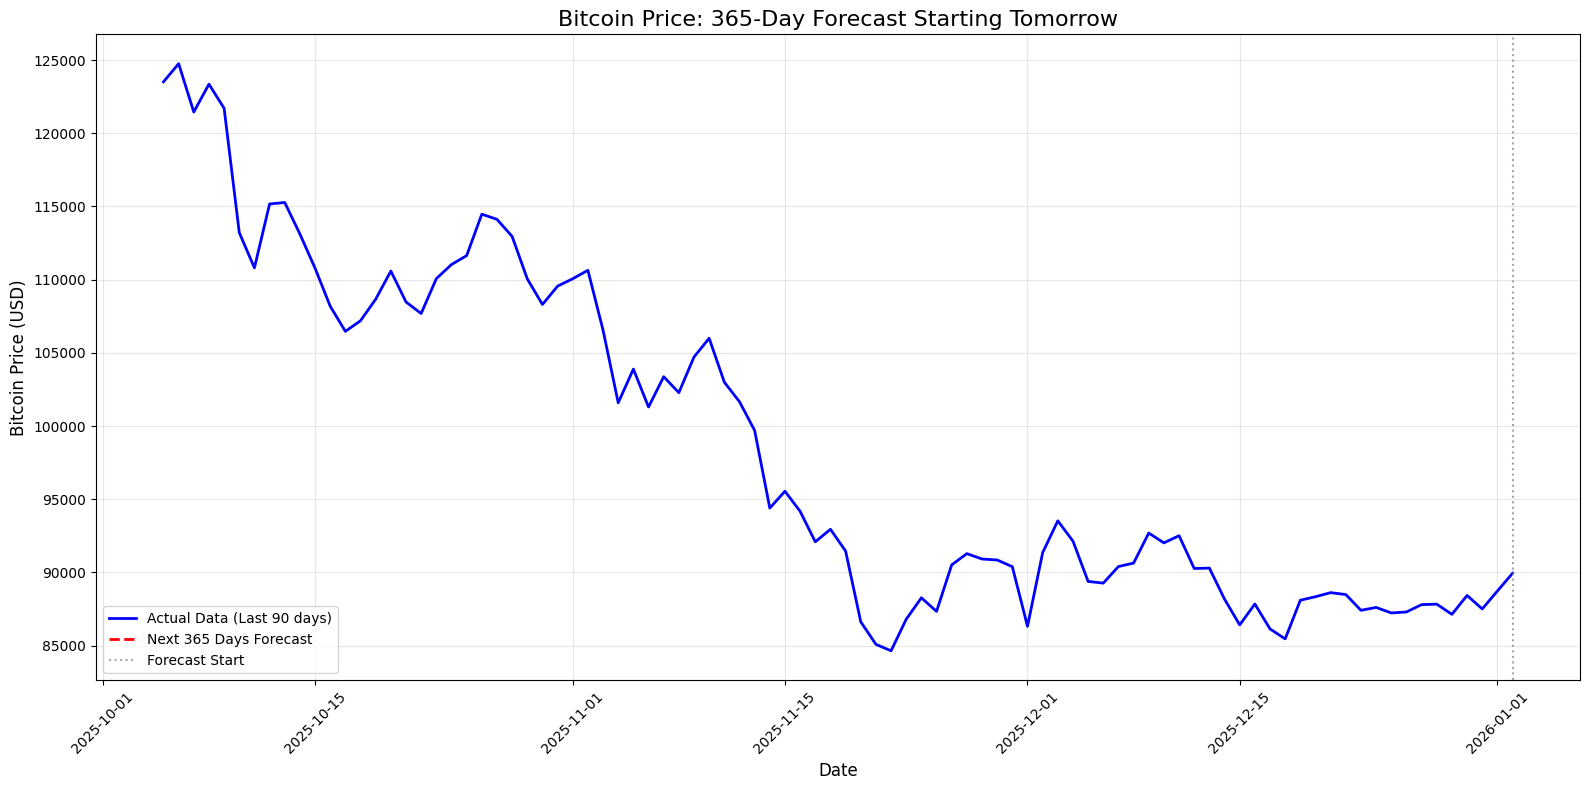


365-Day Forecast Details:
Last actual date: 2026-01-02
Forecast start date: 2026-01-03
Forecast end date: 2027-01-02
Total forecast days: 365

First 10 days forecast:
2026-01-03: $nan
2026-01-04: $nan
2026-01-05: $nan
2026-01-06: $nan
2026-01-07: $nan
2026-01-08: $nan
2026-01-09: $nan
2026-01-10: $nan
2026-01-11: $nan
2026-01-12: $nan

Last 10 days forecast:
2026-12-24: $nan
2026-12-25: $nan
2026-12-26: $nan
2026-12-27: $nan
2026-12-28: $nan
2026-12-29: $nan
2026-12-30: $nan
2026-12-31: $nan
2027-01-01: $nan
2027-01-02: $nan

Forecast saved to 'bitcoin_365_day_forecast.csv'


In [194]:
# Generate forecast starting from next day after last data point
def generate_next_365_days_forecast(model, full_data, days=365):
    """
    Generate forecast for next 365 days starting from the day after last data point
    """
    # Get the last date from your actual data
    last_date = full_data.index[-1]

    # Generate future dates starting from next day
    future_dates = pd.date_range(
        start=last_date + pd.Timedelta(days=1),
        periods=days,
        freq='D'
    )

    # Generate forecast
    forecast_values = model.forecast(steps=days)

    # Create forecast series with proper dates
    forecast_series = pd.Series(forecast_values, index=future_dates)

    return forecast_series


# Generate the 365-day forecast
print("Generating 365-day forecast starting from next day...")
next_365_forecast = generate_next_365_days_forecast(sarima_model, df['Close'])

# Create comprehensive forecast plot
plt.figure(figsize=(16, 8))

# Show last 90 days of actual data for context
last_actual_days = 90
plt.plot(df['Close'].tail(last_actual_days).index,
         df['Close'].tail(last_actual_days).values,
         label='Actual Data (Last 90 days)',
         color='blue',
         linewidth=2)

# Plot the 365-day forecast
plt.plot(next_365_forecast.index,
         next_365_forecast.values,
         '--',
         label='Next 365 Days Forecast',
         color='red',
         linewidth=2)

# Add vertical line to separate actual from forecast
plt.axvline(x=df['Close'].index[-1], color='gray',
            linestyle=':', alpha=0.7, label='Forecast Start')

plt.title('Bitcoin Price: 365-Day Forecast Starting Tomorrow', fontsize=16)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Bitcoin Price (USD)', fontsize=12)
plt.legend(fontsize=10)
plt.grid(alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Display forecast information
print(f"\n365-Day Forecast Details:")
print(f"Last actual date: {df['Close'].index[-1].strftime('%Y-%m-%d')}")
print(
    f"Forecast start date: {next_365_forecast.index[0].strftime('%Y-%m-%d')}")
print(f"Forecast end date: {next_365_forecast.index[-1].strftime('%Y-%m-%d')}")
print(f"Total forecast days: {len(next_365_forecast)}")

# Show some sample forecast values
print(f"\nFirst 10 days forecast:")
for i in range(10):
    date = next_365_forecast.index[i]
    price = next_365_forecast.iloc[i]
    print(f"{date.strftime('%Y-%m-%d')}: ${price:,.2f}")

print(f"\nLast 10 days forecast:")
for i in range(-10, 0):
    date = next_365_forecast.index[i]
    price = next_365_forecast.iloc[i]
    print(f"{date.strftime('%Y-%m-%d')}: ${price:,.2f}")

# Save forecast to CSV
forecast_df = pd.DataFrame({
    'Date': next_365_forecast.index,
    'Forecasted_Price': next_365_forecast.values
})
forecast_df.to_csv('bitcoin_365_day_forecast.csv', index=False)
print(f"\nForecast saved to 'bitcoin_365_day_forecast.csv'")

## LSTM

In [199]:
df_lstm = df.copy()
df_lstm.tail()

,Close,High,Low,Open,Volume
Date,,,,,
2025-12-29,87138.140625,90299.156250,86717.914062,87835.789062,48411625849
2025-12-30,88430.132812,89297.937500,86735.546875,87134.351562,35586356225
2025-12-31,87508.828125,89080.289062,87130.562500,88429.585938,33830210616
2026-01-01,88731.984375,88803.226562,87399.406250,87508.046875,18849043990
2026-01-02,89944.695312,90884.460938,88298.617188,88733.062500,46398906171


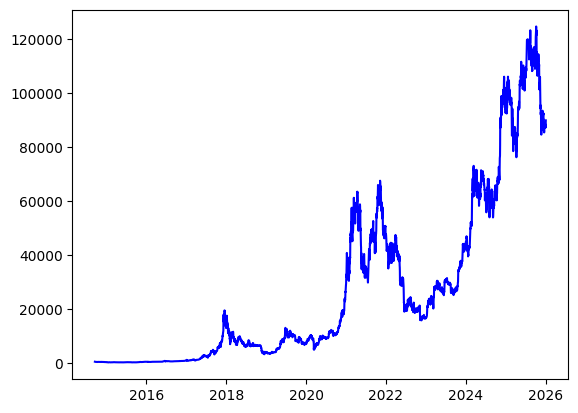

In [200]:
%matplotlib inline
import matplotlib.pyplot as plt

plt.plot(df_lstm.index, df_lstm['Close'], color='blue')
plt.show()

### Preprocessing

In [201]:
import numpy as np
import pandas as pd


def df_to_windowed_df(dataframe, first_date_str, last_date_str, window_size=5):
    """Convert DataFrame to windowed DataFrame for time series analysis."""

    first_date = pd.to_datetime(first_date_str)
    last_date = pd.to_datetime(last_date_str)

    # Filter dataframe by date range
    df_filtered = dataframe.loc[
        (dataframe.index >= first_date) & (dataframe.index <= last_date)
    ].copy()

    # Create lagged features (previous date values)
    for i in range(1, window_size + 1):
        df_filtered[f'Close_lag_{i}'] = df_filtered['Close'].shift(i)

    # Target is the current date's Close value
    df_filtered['Target'] = df_filtered['Close']

    # Drop rows with NaN values created by shifting
    df_windowed = df_filtered.dropna()

    # Reorder columns: Close_lag_5, Close_lag_4, ..., Close_lag_1, Target
    lag_cols = [f'Close_lag_{i}' for i in range(window_size, 0, -1)]
    df_windowed = df_windowed[lag_cols + ['Target']]

    return df_windowed


df_windowed = df_to_windowed_df(df_lstm, '2024-12-31', '2025-12-31', window_size=5)
df_windowed.tail()

,Close_lag_5,Close_lag_4,Close_lag_3,Close_lag_2,Close_lag_1,Target
Date,,,,,,
2025-12-27,88490.015625,87414.000000,87611.960938,87234.742188,87301.429688,87802.156250
2025-12-28,87414.000000,87611.960938,87234.742188,87301.429688,87802.156250,87835.835938
2025-12-29,87611.960938,87234.742188,87301.429688,87802.156250,87835.835938,87138.140625
2025-12-30,87234.742188,87301.429688,87802.156250,87835.835938,87138.140625,88430.132812
2025-12-31,87301.429688,87802.156250,87835.835938,87138.140625,88430.132812,87508.828125


In [202]:
def windowed_df_to_date_X_y(windowed_dataframe):
    """
    Convert windowed DataFrame into dates, X, y arrays.
    Assumes:
    - Index is Date
    - Columns: Close_lag_n ... Close_lag_1, Target
    """

    # Dates come from the index
    dates = windowed_dataframe.index.to_numpy()

    # Convert dataframe to numpy
    df_as_np = windowed_dataframe.to_numpy()

    # X = all lag columns (everything except last column)
    X = df_as_np[:, :-1]

    print(f"X shape before reshape: {X.shape}")

    # Reshape X to (samples, timesteps, features)
    X = X.reshape((len(dates), X.shape[1], 1))

    print(f"X shape after reshape: {X.shape}")
    # y = Target column
    y = df_as_np[:, -1]

    return dates, X.astype(np.float32), y.astype(np.float32)

In [203]:
dates, X, y = windowed_df_to_date_X_y(df_windowed)
dates.shape, X.shape, y.shape

X shape before reshape: (361, 5)
X shape after reshape: (361, 5, 1)


((361,), (361, 5, 1), (361,))

In [204]:
df_windowed.shape

(361, 6)

### Spliting the Dataset into Train and Test

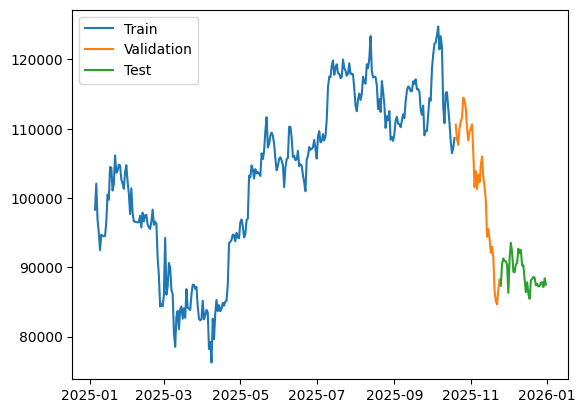

In [205]:
q_80 = int(len(dates) * .8)
q_90 = int(len(dates) * .9)

dates_train, X_train, y_train = dates[:q_80], X[:q_80], y[:q_80]
dates_val, X_val, y_val = dates[q_80:q_90], X[q_80:q_90], y[q_80:q_90]
dates_test, X_test, y_test = dates[q_90:], X[q_90:], y[q_90:]


plt.plot(dates_train, y_train, label='Train')
plt.plot(dates_val, y_val, label='Validation')
plt.plot(dates_test, y_test, label='Test')
plt.legend()
plt.show()

### Train the Model

In [210]:
import numpy as np
import matplotlib.pyplot as plt
from keras.models import Sequential
from keras.optimizers import Adam
from keras import layers
from keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score


print("\n" + "="*60)
print("DATA SCALING")
print("="*60)

scaler_X = StandardScaler()
scaler_y = StandardScaler()


def scale_data(X_train, X_val, X_test, y_train, y_val, y_test):
    """Scale features and target variables."""

    # Scale X features
    if len(X_train.shape) == 3:
        X_train_reshaped = X_train.reshape(-1, X_train.shape[-1])
        X_val_reshaped = X_val.reshape(-1, X_val.shape[-1])
        X_test_reshaped = X_test.reshape(-1, X_test.shape[-1])

        X_train_scaled = scaler_X.fit_transform(
            X_train_reshaped).reshape(X_train.shape)
        X_val_scaled = scaler_X.transform(X_val_reshaped).reshape(X_val.shape)
        X_test_scaled = scaler_X.transform(
            X_test_reshaped).reshape(X_test.shape)
    else:
        X_train_scaled = scaler_X.fit_transform(X_train)
        X_val_scaled = scaler_X.transform(X_val)
        X_test_scaled = scaler_X.transform(X_test)

    # Scale y target
    y_train_scaled = scaler_y.fit_transform(y_train.reshape(-1, 1)).flatten()
    y_val_scaled = scaler_y.transform(y_val.reshape(-1, 1)).flatten()
    y_test_scaled = scaler_y.transform(y_test.reshape(-1, 1)).flatten()

    return X_train_scaled, X_val_scaled, X_test_scaled, y_train_scaled, y_val_scaled, y_test_scaled


# Apply scaling
X_train_scaled, X_val_scaled, X_test_scaled, y_train_scaled, y_val_scaled, y_test_scaled = scale_data(
    X_train, X_val, X_test, y_train, y_val, y_test
)

print(f"X_train_scaled shape: {X_train_scaled.shape}")
print(
    f"X_train_scaled mean: {X_train_scaled.mean():.4f}, std: {X_train_scaled.std():.4f}")
print(
    f"y_train_scaled mean: {y_train_scaled.mean():.4f}, std: {y_train_scaled.std():.4f}")


DATA SCALING
X_train_scaled shape: (288, 5, 1)
X_train_scaled mean: 0.0000, std: 1.0000
y_train_scaled mean: 0.0000, std: 1.0000


In [211]:
print("\n" + "="*60)
print("BUILDING LSTM MODEL")
print("="*60)


def build_lstm_model(input_shape=(3, 1)):
    """Build and return an LSTM model."""

    model = Sequential([
        layers.Input(input_shape),
        layers.LSTM(128, return_sequences=True,
                    kernel_initializer='glorot_uniform'),
        layers.Dropout(0.2),
        layers.LSTM(64, return_sequences=True,
                    kernel_initializer='glorot_uniform'),
        layers.Dropout(0.2),
        layers.LSTM(32, kernel_initializer='glorot_uniform'),
        layers.Dropout(0.2),
        layers.Dense(16, activation='relu'),
        layers.Dense(8, activation='relu'),
        layers.Dense(1)
    ])

    optimizer = Adam(
        learning_rate=0.001,
        beta_1=0.9,
        beta_2=0.999,
        epsilon=1e-07
    )

    model.compile(
        loss='mse',
        optimizer=optimizer,
        metrics=['mean_absolute_error', 'mean_squared_error']
    )

    return model


# Build model
model = build_lstm_model(input_shape=(
    X_train_scaled.shape[1], X_train_scaled.shape[2]))
print("Model Summary:")
model.summary()


BUILDING LSTM MODEL
Model Summary:


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_9 (LSTM)                   │ (None, 5, 128)         │        66,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 5, 128)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_10 (LSTM)                  │ (None, 5, 64)          │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 5, 64)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_11 (LSTM)                  │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 129,057 (504.13 KB)

 Trainable params: 129,057 (504.13 KB)

 Non-trainable params: 0 (0.00 B)

In [212]:
print("\n" + "="*60)
print("SETTING UP TRAINING CALLBACKS")
print("="*60)


def get_training_callbacks():
    """Create and return training callbacks."""

    early_stopping = EarlyStopping(
        monitor='val_loss',
        patience=20,
        restore_best_weights=True,
        verbose=1
    )

    reduce_lr = ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=10,
        min_lr=0.00001,
        verbose=1
    )

    return [early_stopping, reduce_lr]


callbacks = get_training_callbacks()
print("Callbacks created: EarlyStopping, ReduceLROnPlateau")


SETTING UP TRAINING CALLBACKS
Callbacks created: EarlyStopping, ReduceLROnPlateau


In [213]:
print("\n" + "="*60)
print("TRAINING MODEL")
print("="*60)

history = model.fit(
    X_train_scaled,
    y_train_scaled,
    validation_data=(X_val_scaled, y_val_scaled),
    epochs=200,
    batch_size=32,
    callbacks=callbacks,
    verbose=1
)

print(f"\nTraining completed after {len(history.history['loss'])} epochs")
print(f"Final training loss: {history.history['loss'][-1]:.4f}")
print(f"Final validation loss: {history.history['val_loss'][-1]:.4f}")


TRAINING MODEL
Epoch 1/200
9/9 ━━━━━━━━━━━━━━━━━━━━ 2s 36ms/step - loss: 0.9015 - mean_absolute_error: 0.8002 - mean_squared_error: 0.9015 - val_loss: 0.4136 - val_mean_absolute_error: 0.5488 - val_mean_squared_error: 0.4136 - learning_rate: 0.0010
Epoch 2/200
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.5968 - mean_absolute_error: 0.6414 - mean_squared_error: 0.5968 - val_loss: 0.2080 - val_mean_absolute_error: 0.3844 - val_mean_squared_error: 0.2080 - learning_rate: 0.0010
Epoch 3/200
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.5088 - mean_absolute_error: 0.5748 - mean_squared_error: 0.5088 - val_loss: 0.2469 - val_mean_absolute_error: 0.4327 - val_mean_squared_error: 0.2469 - learning_rate: 0.0010
Epoch 4/200
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.4724 - mean_absolute_error: 0.5432 - mean_squared_error: 0.4724 - val_loss: 0.2352 - val_mean_absolute_error: 0.4171 - val_mean_squared_error: 0.2352 - learning_rate: 0.0010
Epoch 5/200
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - 

### Make Prediction

In [215]:
print("\n" + "="*60)
print("MAKING PREDICTIONS")
print("="*60)


def make_predictions(model, X_train_scaled, X_val_scaled, X_test_scaled):
    """Make predictions on all datasets."""

    train_predictions_scaled = model.predict(
        X_train_scaled, verbose=0).flatten()
    val_predictions_scaled = model.predict(X_val_scaled, verbose=0).flatten()
    test_predictions_scaled = model.predict(X_test_scaled, verbose=0).flatten()

    # Inverse transform to original scale
    train_predictions = scaler_y.inverse_transform(
        train_predictions_scaled.reshape(-1, 1)).flatten()
    val_predictions = scaler_y.inverse_transform(
        val_predictions_scaled.reshape(-1, 1)).flatten()
    test_predictions = scaler_y.inverse_transform(
        test_predictions_scaled.reshape(-1, 1)).flatten()

    return train_predictions, val_predictions, test_predictions


train_predictions, val_predictions, test_predictions = make_predictions(
    model, X_train_scaled, X_val_scaled, X_test_scaled
)

print(f"Predictions made on {len(train_predictions)} training samples")
print(f"Predictions made on {len(val_predictions)} validation samples")
print(f"Predictions made on {len(test_predictions)} test samples")


MAKING PREDICTIONS
Predictions made on 288 training samples
Predictions made on 36 validation samples
Predictions made on 37 test samples


### Visualization


PLOTTING RESULTS


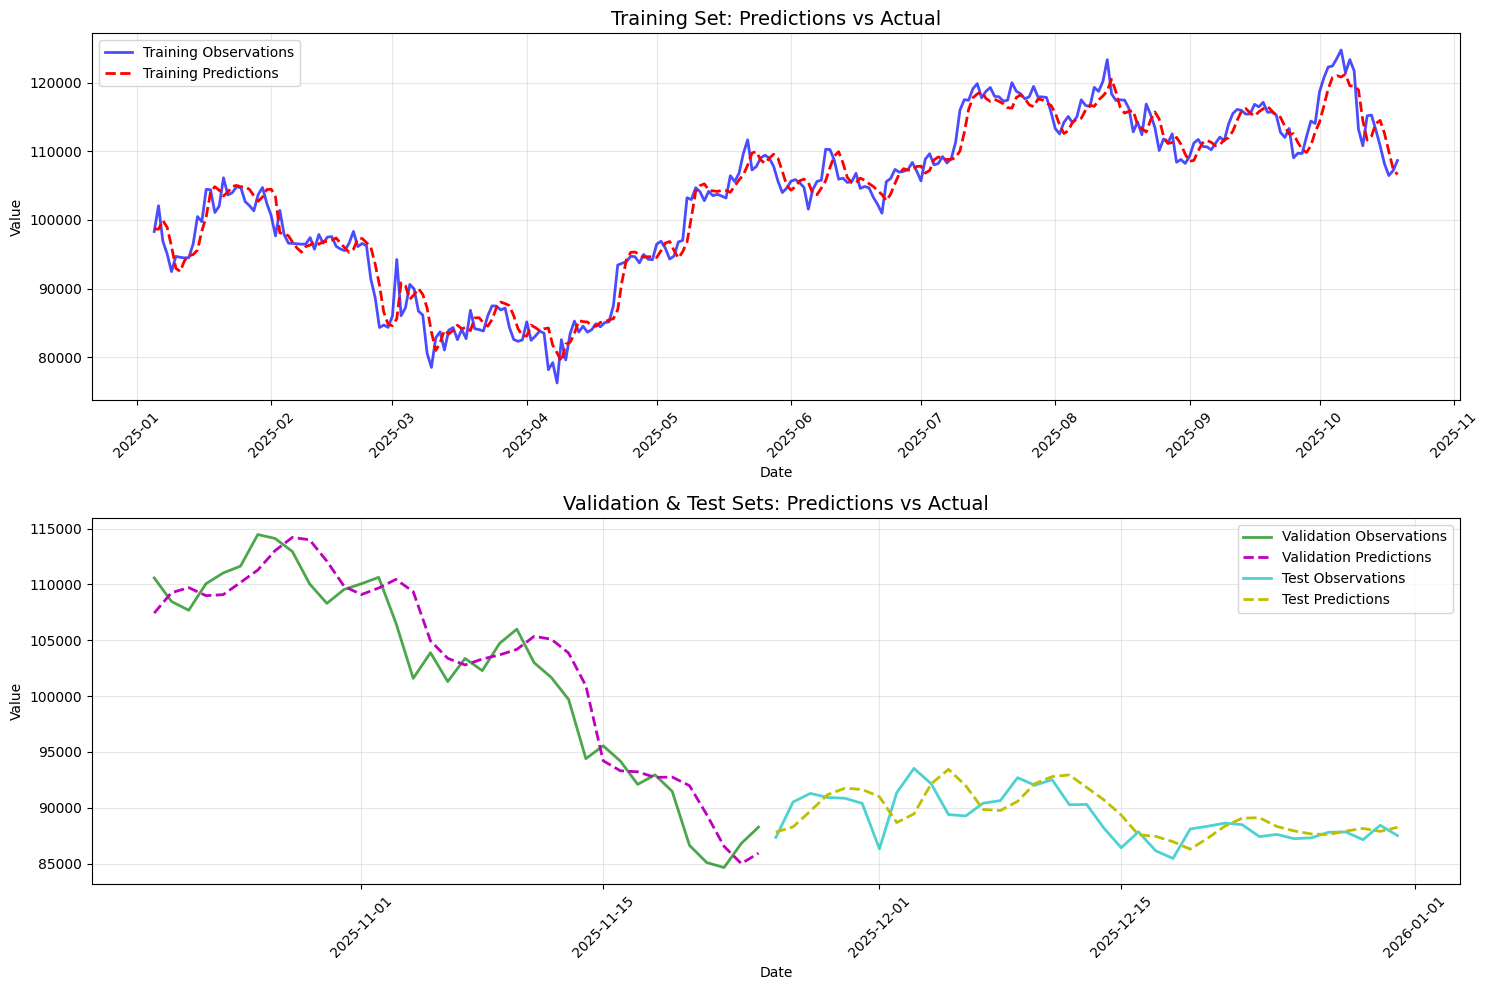

In [216]:
print("\n" + "="*60)
print("PLOTTING RESULTS")
print("="*60)


def plot_predictions(dates_train, y_train, train_predictions,
                     dates_val, y_val, val_predictions,
                     dates_test, y_test, test_predictions):
    """Plot predictions vs actual values."""

    fig, axes = plt.subplots(2, 1, figsize=(15, 10))

    # Plot training data
    axes[0].plot(dates_train, y_train, 'b-', label='Training Observations',
                 linewidth=2, alpha=0.7)
    axes[0].plot(dates_train, train_predictions, 'r--',
                 label='Training Predictions', linewidth=2)
    axes[0].set_title('Training Set: Predictions vs Actual', fontsize=14)
    axes[0].set_xlabel('Date')
    axes[0].set_ylabel('Value')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)
    axes[0].tick_params(axis='x', rotation=45)

    # Plot validation and test
    axes[1].plot(dates_val, y_val, 'g-', label='Validation Observations',
                 linewidth=2, alpha=0.7)
    axes[1].plot(dates_val, val_predictions, 'm--',
                 label='Validation Predictions', linewidth=2)
    axes[1].plot(dates_test, y_test, 'c-', label='Test Observations',
                 linewidth=2, alpha=0.7)
    axes[1].plot(dates_test, test_predictions, 'y--',
                 label='Test Predictions', linewidth=2)
    axes[1].set_title(
        'Validation & Test Sets: Predictions vs Actual', fontsize=14)
    axes[1].set_xlabel('Date')
    axes[1].set_ylabel('Value')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)
    axes[1].tick_params(axis='x', rotation=45)

    plt.tight_layout()
    plt.show()

    return fig


# Create predictions plot
prediction_plot = plot_predictions(
    dates_train, y_train, train_predictions,
    dates_val, y_val, val_predictions,
    dates_test, y_test, test_predictions
)

### Evaluation

In [218]:
print("\n" + "="*60)
print("EVALUATION METRICS")
print("="*60)


def calculate_metrics(y_true, y_pred, dataset_name):
    """Calculate and display evaluation metrics."""

    mse = mean_squared_error(y_true, y_pred)
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, y_pred)

    print(f"\n{dataset_name} Set:")
    print(f"  MSE: {mse:.4f}")
    print(f"  MAE: {mae:.4f}")
    print(f"  RMSE: {rmse:.4f}")
    print(f"  R² Score: {r2:.4f}")
    print(f"  Predictions range: [{y_pred.min():.4f}, {y_pred.max():.4f}]")
    print(f"  Actual range: [{y_true.min():.4f}, {y_true.max():.4f}]")

    return {'mse': mse, 'mae': mae, 'rmse': rmse, 'r2': r2}


# Calculate metrics for all datasets
metrics = {}
metrics['train'] = calculate_metrics(y_train, train_predictions, "Training")
metrics['val'] = calculate_metrics(y_val, val_predictions, "Validation")
metrics['test'] = calculate_metrics(y_test, test_predictions, "Test")

# Print summary
print("\n" + "="*60)
print("PERFORMANCE SUMMARY")
print("="*60)
print(f"{'Dataset':<15} {'MSE':<10} {'MAE':<10} {'RMSE':<10} {'R²':<10}")
print("-"*60)
for dataset in ['train', 'val', 'test']:
    m = metrics[dataset]
    print(
        f"{dataset.capitalize():<15} {m['mse']:<10.4f} {m['mae']:<10.4f} {m['rmse']:<10.4f} {m['r2']:<10.4f}")


EVALUATION METRICS

Training Set:
  MSE: 5395914.0000
  MAE: 1784.0189
  RMSE: 2322.9106
  R² Score: 0.9617
  Predictions range: [79396.8906, 121235.0781]
  Actual range: [76271.9531, 124752.5312]

Validation Set:
  MSE: 8198682.0000
  MAE: 2282.1443
  RMSE: 2863.3340
  R² Score: 0.8969
  Predictions range: [85002.1016, 114214.0000]
  Actual range: [84648.3594, 114472.4453]

Test Set:
  MSE: 3358418.2500
  MAE: 1387.3108
  RMSE: 1832.5988
  R² Score: 0.1995
  Predictions range: [86290.4297, 93441.7422]
  Actual range: [85462.5078, 93527.8047]

PERFORMANCE SUMMARY
Dataset         MSE        MAE        RMSE       R²        
------------------------------------------------------------
Train           5395914.0000 1784.0189  2322.9106  0.9617    
Val             8198682.0000 2282.1443  2863.3340  0.8969    
Test            3358418.2500 1387.3108  1832.5988  0.1995    


## Prophet

### Imports and Visualization

In [219]:
from prophet import Prophet

In [220]:
df_prophet = df.copy()
df_prophet.tail()

,Close,High,Low,Open,Volume
Date,,,,,
2025-12-29,87138.140625,90299.156250,86717.914062,87835.789062,48411625849
2025-12-30,88430.132812,89297.937500,86735.546875,87134.351562,35586356225
2025-12-31,87508.828125,89080.289062,87130.562500,88429.585938,33830210616
2026-01-01,88731.984375,88803.226562,87399.406250,87508.046875,18849043990
2026-01-02,89944.695312,90884.460938,88298.617188,88733.062500,46398906171


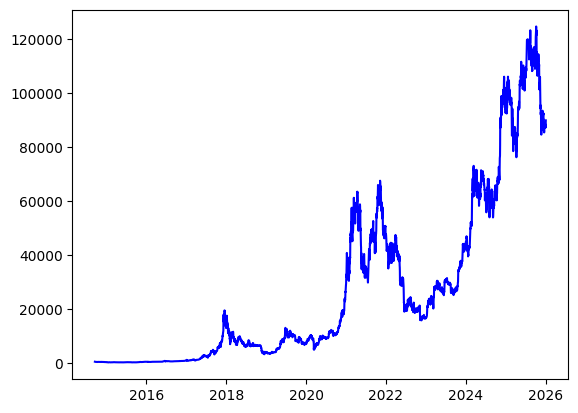

In [221]:
%matplotlib inline
import matplotlib.pyplot as plt

plt.plot(df_prophet.index, df_prophet['Close'], color='blue')
plt.show()

### Renaming the Columns

In [222]:
df_prophet["ds"] = pd.to_datetime(df_prophet.index)
df_prophet["y"] = df_prophet["Close"]

df_prophet = df_prophet[["ds", "y"]].sort_values("ds").reset_index(drop=True)

In [223]:
df_prophet.tail()

,ds,y
4121,2025-12-29,87138.140625
4122,2025-12-30,88430.132812
4123,2025-12-31,87508.828125
4124,2026-01-01,88731.984375
4125,2026-01-02,89944.695312


### Training The Model

In [224]:
prophet = Prophet(daily_seasonality=True, yearly_seasonality=True)
prophet.fit(df_prophet)

12:56:51 - cmdstanpy - INFO - Chain [1] start processing
12:56:52 - cmdstanpy - INFO - Chain [1] done processing


### Future Prediction

In [225]:
future = prophet.make_future_dataframe(
    periods=365)  # Forecast 365 days into future
forecast = prophet.predict(future)

### Plot

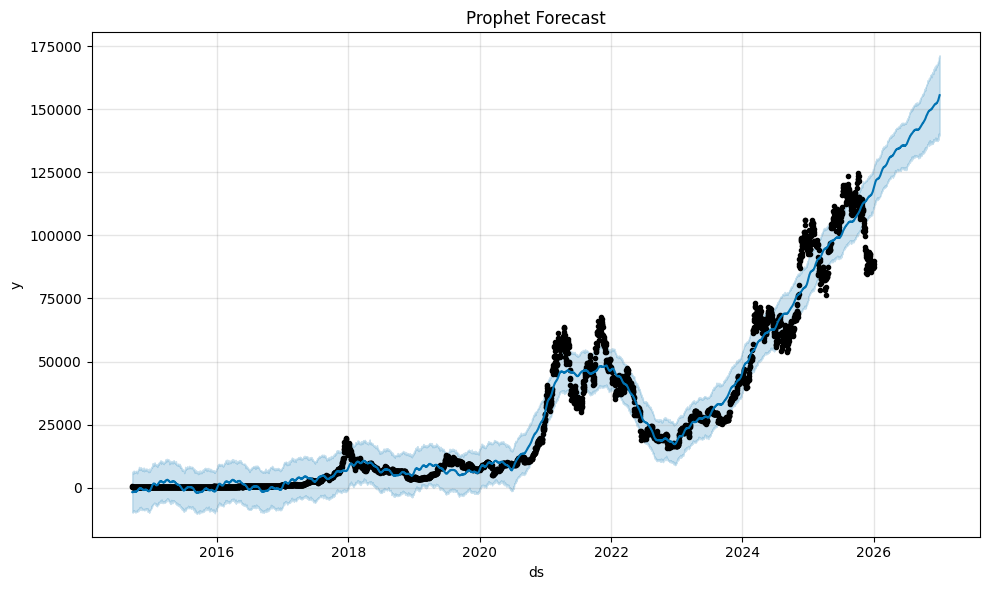

In [226]:
# 5. Plot (matplotlib only - no Plotly)
fig = prophet.plot(forecast)
plt.title('Prophet Forecast')
plt.tight_layout()
plt.show()